# Loop Engineering, by Hand — a Weekly Competitor-Listening Agent
**TEMPLATE — fill in the 👉 [ADD ... HERE] blanks, then Run all. (An introductory demo of loop engineering.)**

### Point it at your product and its rivals. Every week it listens across open platforms (Bluesky, Hacker News, Reddit), measures the mood, models the topics, and drafts you a Monday email showing where you're winning, losing, and the gaps to attack. Open models, no API keys.

**Created by Dr. Jeanne McClure · Ars Innovate.** Licensed **[CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/)** — free to use, share, and adapt for non-commercial purposes **with attribution**. I put real work into sharing these resources; if it helps you, please keep the credit and pass it on. 🙏

> ⚠️ **FIRST: make a copy** — *File → Save a copy in Drive* — or nothing you change is saved.

**The one big idea — *who owns the loop?***

| | Part A · **You** engineer the loop | Part B · The **agent** engineers its own loop |
|---|---|---|
| Pattern | the **Ralph loop** (Geoffrey Huntley) | an **agentic** loop (BeeAI) |
| Who decides the steps | **you** — one process, watched | the **model** — it plans and acts |
| Your control point | the code + a kill switch | the tools you allow + what you accept |

**Right tool for each step (this is the point):** cheap, validated tools do the grunt work for *zero tokens*; the LLM is saved for the one thing only it can do — strategy.

| Step | Tool | Token cost |
|---|---|---|
| Listen (Bluesky + Hacker News + Reddit) | open APIs | 0 |
| Sentiment | **VADER** (NLTK) — validated for social text | 0 |
| Topics | **BERTopic** (BERT embeddings + c-TF-IDF) | 0 |
| Interpret · find gaps · propose new signals | **IBM Granite** (open LLM) | a little — only here |
| Deliver · ask what to watch next | a Monday-morning email you can reply to | 0 |

**Credit:** the *loop* is the **Ralph loop**, coined by **Geoffrey Huntley** (framed by IBM as Goal → Action → Observation → Adjustment). Open model: **IBM Granite**; agent framework: **BeeAI** (created by IBM, now a Linux Foundation project). NLP: **VADER** (Hutto & Gilbert, 2014), **BERTopic** (Grootendorst, 2022), **scikit-learn**. **ICI** (Instruction·Context·Input) and **From Vibes to Evidence** © Dr. Jeanne McClure / Ars Innovate.


## ▶️ New to Colab? Here's all you do

You don't need to write any code — every grey cell runs itself.

1. **Runtime → Change runtime type → T4 GPU → Save**
2. **Runtime → Run all** (top menu) — or click each cell and press **Shift + Enter**, top to bottom
3. The first setup cell takes ~3 minutes. Wait for the ✅ before moving on.
4. Make it yours: fill in the spots marked **👉 `[ADD ... HERE]`** (your product, its competitors, and — for email — your address), then **Run all** again.

Each step below explains itself in plain language before the code runs.

## Before we start — what's an *agent*, and what's *loop engineering*?

An **agent** is an LLM that doesn't just answer once. It runs in a **loop**: look at a goal → take an action (search, read, use a tool) → look at the result → decide the next step → repeat, until the job is done. This notebook builds one.

There are three ways to steer an LLM. They **stack** — loop engineering usually uses the other two *inside* it.

| Approach | What you shape | Reach for it when |
|---|---|---|
| **Prompt engineering** | the wording of a single request | you want one good answer — *"summarize this", "rewrite that"* |
| **Context engineering** | what the model can *see* — docs, data, memory, tools | the model needs the right facts or tools in front of it to answer well |
| **Loop engineering** | the *steps* the model repeats — gather, reason, check, adjust | the work takes many steps, or has to run again and again (like this weekly agent) |

**Rule of thumb:** one good answer → *prompt*. The right information → *context*. A job that repeats or runs itself → **loop**. This notebook is all about that third one.

> *Why it matters here:* a loop lets you use a **cheap, validated tool** for each small job and save the **LLM** for the one step only it can do. That decision — which engine per step — is the craft.

## First — why build this by hand?

When you use an AI agent — **Claude**, or any other — a loop is running that you never see: it reads, reasons, checks its work, adjusts, and goes again. That loop is the whole game; it's just hidden inside a product.

This notebook builds that loop by hand so **every part is visible and yours to change** — including the most valuable decision in loop engineering: *which step deserves an expensive LLM, and which doesn't.* Here, only one step needs the LLM at all — the rest run on free, validated tools. The model shows up only for strategy, and you watch exactly what that costs.

## The loop at a glance

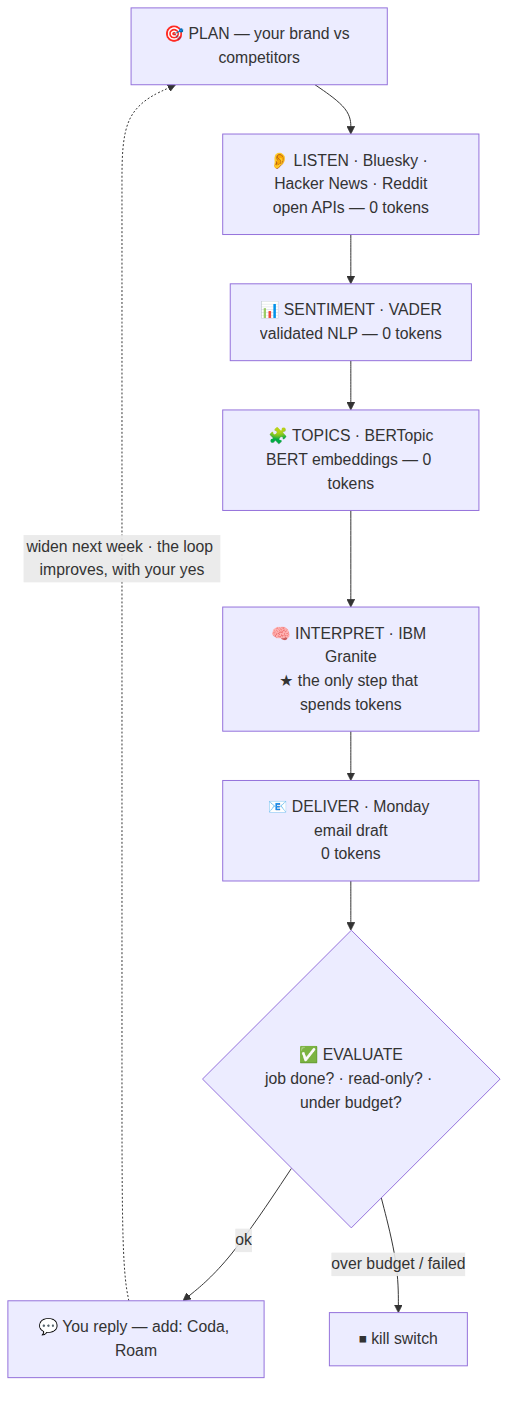

*Three-quarters of the work runs on free, validated tools; the LLM shows up once, for judgment; a kill switch caps the cost; and every Monday you approve what to watch next — so the loop improves with your yes.*

## ⚙️ Setup
Enable a GPU: **Runtime → Change runtime type → T4 GPU → Save.** Then run the three cells below (~3 min the first time).

In [ ]:
# Setup 1 — install Ollama, start it, pull the NEWEST IBM Granite we can get.
import subprocess, time, requests

# Newest → oldest. When IBM ships a newer small Granite, add its tag to the TOP.
GRANITE_CANDIDATES = ['granite4.1:3b', 'granite3.3:2b']

def installed_models():
    try:
        return [m['name'] for m in requests.get('http://localhost:11434/api/tags', timeout=5).json().get('models', [])]
    except Exception:
        return None

present = installed_models()
if present is None:
    print('Setting up Ollama from scratch…')
    subprocess.run('apt-get install -y zstd', shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run('curl -fsSL https://ollama.com/install.sh | sh', shell=True)
    subprocess.Popen('ollama serve', shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(6)
    present = installed_models() or []

MODEL = None
for tag in GRANITE_CANDIDATES:
    if tag in present:
        MODEL = tag; print(f'✅ already downloaded: {tag}'); break
    print(f'⤵️  trying to pull {tag} …')
    if subprocess.run(f'ollama pull {tag}', shell=True).returncode == 0:
        MODEL = tag; print(f'✅ pulled {tag}'); break
    print(f'   {tag} not available — trying the next one down…')

if not MODEL:
    print('❌ Could not get any Granite model. Check GPU runtime + network, then re-run.')
else:
    print(f'\n👉 Using MODEL = {MODEL}')
    if MODEL != GRANITE_CANDIDATES[0]:
        print(f'   (heads-up: {GRANITE_CANDIDATES[0]} would be newer, but it did not pull.)')

In [ ]:
# Setup 2 — Python packages: agent framework + NLP (VADER, BERTopic, scikit-learn)
# (BERTopic pulls sentence-transformers/umap/hdbscan — the biggest install here, ~1–2 min.)
import subprocess
subprocess.run('pip install -q "beeai-framework[wikipedia]" bertopic nltk scikit-learn pandas requests', shell=True)
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
print('✅ installed')

In [ ]:
# Setup 3 — one helper to ask Granite, metering its tokens (so we can price it + know when to kill it)
import requests
USAGE = {'tokens': 0, 'calls': 0}

def ask_granite(prompt, system='You are a helpful assistant.'):
    r = requests.post('http://localhost:11434/api/chat', json={
        'model': MODEL,
        'messages':[{'role':'system','content':system},{'role':'user','content':prompt}],
        'stream': False,
    }).json()
    USAGE['tokens'] += r.get('prompt_eval_count', 0) + r.get('eval_count', 0)
    USAGE['calls']  += 1
    return r['message']['content']

print(ask_granite('In one sentence, what is competitor social listening?'))

---
# Part A · **You** engineer the loop — the *Ralph loop*

> *"You shouldn't be prompting your agents. You should be designing loops that prompt your agents."* — the Ralph mindset (Geoffrey Huntley)

One process, one job, watched by you. Below, each step is a function; you decide what runs on a free tool and where the LLM is worth paying for.

### Step 1 · Your Listening Plan — you vs your competitors
The spec the loop runs. Look for the **👉 `[ADD ... HERE]`** markers and drop in your own product and its rivals. (It's set to Notion vs. its rivals so it runs as-is.)

In [ ]:
# Fill in the 👉 blanks, then Run all.  (Left unfilled? It uses the Notion example so you still see it work.)
PLAN = {
    'brand'       : '[ADD YOUR PRODUCT HERE]',                                            # 👉 your product
    'competitors' : ['[ADD COMPETITOR 1]', '[ADD COMPETITOR 2]', '[ADD COMPETITOR 3]'],   # 👉 its rivals
    'exclude'     : [],                                        # 👉 words to drop (homonym noise) — optional
    'min_sources' : 4,                                         # kill-switch: too little evidence → stop
    'goal'        : 'see where we win, where we lose, and the gaps to attack',
}
if '[ADD' in PLAN['brand'] or any('[ADD' in b for b in PLAN['competitors']):
    print('👉 Fill Step 1 with your product + competitors. Using the Notion example for now so you can see it run.')
    PLAN.update(brand='Notion', competitors=['Obsidian', 'Airtable', 'ClickUp', 'Evernote'],
                exclude=['notion of', 'the notion', 'a notion', 'minecraft'])
PLAN['brands'] = [PLAN['brand']] + PLAN['competitors']         # everything we track
print('Tracking:', ', '.join(PLAN['brands']), '\nGoal:', PLAN['goal'])

### Step 2 · Gather — fan out across **multiple sources**
Real research never trusts one place. We pull **Bluesky** (social) + **Hacker News** (forums/news) — both open, no key — plus **Reddit** (deep discussion) when you add free credentials. We search every brand, de-dup, and keep only posts that actually name a brand.

Each source is just a function returning `{source, author, text, url}` — add RSS or review sites the same way. Any source that's unreachable or unconfigured just skips; the loop keeps going.

In [ ]:
import urllib.request, urllib.parse, json, re

SAMPLE = [  # only used if EVERY live source is unreachable
    {'source':'bluesky','author':'@a','text':'Notion is great for organizing everything in one place. Love it.','url':'https://bsky.app/x/1'},
    {'source':'bluesky','author':'@b','text':'Notion gets painfully slow once my database grows. Big lag.','url':'https://bsky.app/x/2'},
    {'source':'bluesky','author':'@c','text':'Obsidian is so much faster than Notion and works offline. Love it.','url':'https://bsky.app/x/3'},
    {'source':'bluesky','author':'@d','text':'Airtable pricing is brutal for a small team. Getting expensive.','url':'https://bsky.app/x/4'},
    {'source':'bluesky','author':'@e','text':'ClickUp has a rough learning curve, overwhelmed by features.','url':'https://bsky.app/x/5'},
    {'source':'bluesky','author':'@f','text':'Evernote finally feels fast again, genuinely recommend for notes.','url':'https://bsky.app/x/6'},
]

def search_bluesky(query, limit=25):
    url = 'https://public.api.bsky.app/xrpc/app.bsky.feed.searchPosts?' + urllib.parse.urlencode({'q':query,'limit':limit})
    req = urllib.request.Request(url, headers={'User-Agent':'ralph-loop'})
    with urllib.request.urlopen(req, timeout=20) as r:
        data = json.load(r)
    out=[]
    for p in data.get('posts',[]):
        h=p['author']['handle']
        out.append({'source':'bluesky','author':'@'+h,
                    'text':p['record'].get('text','').replace(chr(10),' ').strip(),
                    'url':f"https://bsky.app/profile/{h}/post/{p['uri'].split('/')[-1]}"})
    return out

def search_hn(query, limit=25):
    url = 'https://hn.algolia.com/api/v1/search?' + urllib.parse.urlencode(
        {'query':query,'tags':'(story,comment)','hitsPerPage':limit})
    req = urllib.request.Request(url, headers={'User-Agent':'ralph-loop'})
    with urllib.request.urlopen(req, timeout=20) as r:
        data = json.load(r)
    out=[]
    for h in data.get('hits',[]):
        text = h.get('title') or h.get('story_title') or h.get('comment_text') or h.get('story_text') or ''
        text = re.sub('<[^>]+>',' ', text).replace(chr(10),' ').strip()
        if not text: continue
        out.append({'source':'hackernews','author':'@'+(h.get('author') or 'hn'),'text':text,
                    'url': h.get('url') or f"https://news.ycombinator.com/item?id={h.get('objectID')}"})
    return out

# ── Source 3: Reddit (deep discussion) — needs FREE credentials (reddit.com/prefs/apps → 'script').
#    Fill REDDIT below to enable; left blank, it just skips. (Anonymous Reddit is blocked from cloud IPs,
#    which is why real listening uses the authenticated API — same as any serious social-listening tool.)
import requests
REDDIT = {'client_id':'', 'client_secret':'', 'username':'', 'password':''}   # 👉 [ADD FREE REDDIT CREDS HERE] — optional
_RTOK = {'t': None}

def search_reddit(query, limit=25):
    if not all(REDDIT.values()):
        raise RuntimeError('Reddit not configured — fill REDDIT to enable')
    if not _RTOK['t']:
        tok = requests.post('https://www.reddit.com/api/v1/access_token',
            auth=(REDDIT['client_id'], REDDIT['client_secret']),
            data={'grant_type':'password','username':REDDIT['username'],'password':REDDIT['password']},
            headers={'User-Agent':'ralph-loop/1.0'}, timeout=20).json()
        _RTOK['t'] = tok['access_token']
    h = {'Authorization': f"bearer {_RTOK['t']}", 'User-Agent':'ralph-loop/1.0'}
    url = 'https://oauth.reddit.com/search?' + urllib.parse.urlencode({'q':query,'limit':limit,'sort':'relevance','type':'link'})
    data = requests.get(url, headers=h, timeout=20).json()
    out=[]
    for c in data.get('data',{}).get('children',[]):
        d=c.get('data',{})
        text=(d.get('title','')+' '+d.get('selftext','')).replace(chr(10),' ').strip()
        if not text: continue
        out.append({'source':'reddit','author':'u/'+(d.get('author') or '?'),'text':text[:500],
                    'url':'https://reddit.com'+d.get('permalink','')})
    return out

SOURCES = [('bluesky', search_bluesky), ('hackernews', search_hn), ('reddit', search_reddit)]

def gather(plan):
    seen, posts = set(), []
    for name, fetch in SOURCES:
        try:
            got = 0
            for brand in plan['brands']:
                for p in fetch(brand):
                    if p['url'] in seen: continue
                    seen.add(p['url']); posts.append(p); got += 1
            print(f'   {name:<11}→ {got} posts')
        except Exception as e:
            print(f'   {name:<11}→ skipped ({type(e).__name__})')
    if not posts:
        print('   [no live source reachable — using sample data]'); posts = list(SAMPLE)
    # tag each post with the brand(s) it names; drop posts that name none
    ex = [x.lower() for x in plan['exclude']]
    tagged=[]
    for p in posts:
        t = p['text'].lower()
        if any(x in t for x in ex): continue
        brands = [b for b in plan['brands'] if b.lower() in t]
        if brands:
            tagged.append({**p, 'brands':brands})
    print(f'   kept {len(tagged)} on-topic posts naming a tracked brand')
    return tagged

posts = gather(PLAN)
posts[:3]

### Step 3 · Sentiment — **VADER** (free, validated, 0 tokens)
VADER (Hutto & Gilbert, 2014) is built for short social text. No hand-made word lists, no LLM tokens — this is the grunt work a validated tool should do.

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
vader = SentimentIntensityAnalyzer()

def add_sentiment(post):
    score = vader.polarity_scores(post['text'])['compound']       # -1 … +1
    label = 'positive' if score > 0.05 else 'negative' if score < -0.05 else 'neutral'
    return {**post, 'sentiment':label, 'score':round(score,3)}

read = [add_sentiment(p) for p in posts]
for r in read[:8]:
    print(f"  [{r['sentiment']:>8} {r['score']:+.2f}] ({','.join(r['brands'])}) {r['text'][:55]}")

### Step 4 · Compare the brands — the evidence table
Sentiment by brand: who's loved, who's not — first as a table, then as a quick chart so it reads at a glance. Still 0 tokens — just counting.

In [ ]:
import pandas as pd

def compare_brands(read, brands):
    rows=[]
    for b in brands:
        sub=[r for r in read if b in r['brands']]
        if not sub: rows.append({'brand':b,'posts':0,'%pos':0,'%neg':0,'avg_score':0.0}); continue
        pos=sum(r['sentiment']=='positive' for r in sub); neg=sum(r['sentiment']=='negative' for r in sub)
        rows.append({'brand':b,'posts':len(sub),
                     '%pos':round(100*pos/len(sub)),'%neg':round(100*neg/len(sub)),
                     'avg_score':round(sum(r['score'] for r in sub)/len(sub),2)})
    return pd.DataFrame(rows).sort_values('avg_score', ascending=False).reset_index(drop=True)

table = compare_brands(read, PLAN['brands'])
table

In [ ]:
# The same table as a picture — easier to read at a glance.
import matplotlib.pyplot as plt

TEAL, RED, SLATE, AMBER = '#1b9e88', '#d1495b', '#3d4a5c', '#e0a458'   # slate / teal / amber
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

t = table[table['posts'] > 0].sort_values('avg_score')
ax1.barh(t['brand'], t['avg_score'], color=[TEAL if v >= 0 else RED for v in t['avg_score']])
ax1.axvline(0, color=SLATE, lw=1)
ax1.set_title('Average sentiment by brand (VADER)', color=SLATE)
ax1.set_xlabel('← more negative        more positive →')

tv = table[table['posts'] > 0].sort_values('posts')
ax2.barh(tv['brand'], tv['posts'], color=AMBER)
ax2.set_title('How much each brand is discussed', color=SLATE)
ax2.set_xlabel('posts found this week')

for ax in (ax1, ax2): ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

### Step 5 · Topic modeling — **BERTopic** (0 tokens)
BERTopic clusters posts by **meaning** (BERT sentence embeddings) and labels each cluster with class-based TF-IDF — far sharper than word-count methods on short, messy social text. Better clusters here means a sharper insight and a better email next. (Light weeks — or if the heavy deps hiccup — fall back to NMF automatically. Still 0 LLM tokens.)

In [ ]:
# BERTopic (BERT embeddings + c-TF-IDF), primary; NMF fallback so this always runs.
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF

def _nmf_topics(docs, n_topics=4, n_words=6):
    if len(docs) < 4: return []
    vec = TfidfVectorizer(max_df=0.9, min_df=1, stop_words='english')
    X = vec.fit_transform(docs)
    k = min(n_topics, X.shape[0], X.shape[1])
    if k < 2: return []
    nmf = NMF(n_components=k, init='nndsvda', random_state=0, max_iter=400).fit(X)
    vocab = vec.get_feature_names_out()
    return [[vocab[i] for i in comp.argsort()[::-1][:n_words]] for comp in nmf.components_]

def model_topics(read, n_topics=4, n_words=6):
    docs = [r['text'] for r in read]
    if len(docs) < 6:
        return _nmf_topics(docs, n_topics, n_words)              # too few to embed — use NMF
    try:
        from bertopic import BERTopic
        from sklearn.cluster import KMeans
        k = min(n_topics, max(2, len(docs)//4))
        model = BERTopic(
            embedding_model='all-MiniLM-L6-v2',                 # small, fast sentence embeddings
            hdbscan_model=KMeans(n_clusters=k, random_state=0), # KMeans avoids all-outliers on small data
            vectorizer_model=CountVectorizer(stop_words='english', ngram_range=(1,2)),
            calculate_probabilities=False, verbose=False)
        model.fit_transform(docs)
        out=[]
        for tid in sorted(t for t in model.get_topics() if t != -1):
            words=[w for w,_ in model.get_topic(tid)][:n_words]
            if words: out.append(words)
        return out or _nmf_topics(docs, n_topics, n_words)
    except Exception as e:
        print('   [BERTopic unavailable:', type(e).__name__, '— using NMF fallback]')
        return _nmf_topics(docs, n_topics, n_words)

topics = model_topics(read)
for i,t in enumerate(topics): print(f'topic {i+1}: {", ".join(t)}')
if not topics: print('(not enough posts this week to model topics — widen the search or window)')

### Step 6 · Interpret — this is where **Granite earns its tokens**
VADER gave us mood, BERTopic gave us the topic clusters. Neither can tell you *what it means*. That's the LLM's one job: read the numbers + clusters and find the **gap and the opportunity**. One call, not one-per-post.

In [ ]:
def interpret(table, topics, plan):
    clusters = '\n'.join(f'- {", ".join(t)}' for t in topics) or '(too little data to model topics)'
    prompt = (
        f"Weekly market read: {plan['brand']} vs competitors.\n\n"
        f"Sentiment by brand (VADER, higher avg_score = better mood):\n{table.to_string(index=False)}\n\n"
        f"Topic clusters across all posts:\n{clusters}\n\n"
        f"As a market analyst, answer using the numbers:\n"
        f"1) How does {plan['brand']} compare to the competitors?\n"
        f"2) What do people PRAISE about a competitor that {plan['brand']} lacks? (the gap)\n"
        f"3) The single biggest opportunity for {plan['brand']} this week.\n"
        f"4) One-line takeaway.\n"
        f"5) NEW SIGNALS: name up to 3 products/competitors that show up in the posts but are NOT in "
        f"the tracked list [{', '.join(plan['brands'])}] and would be worth listening to next week. "
        f"Put them on their own final line starting exactly with 'SIGNALS:' (comma-separated, or 'SIGNALS: none').")
    return ask_granite(prompt, system='Sharp market analyst. Concrete, no fluff, cite the numbers.')

def proposed_signals(insight_text):
    for line in insight_text.splitlines():
        if line.strip().upper().startswith('SIGNALS:'):
            raw = line.split(':',1)[1]
            return [s.strip() for s in raw.split(',') if s.strip() and s.strip().lower() != 'none']
    return []

insight = interpret(table, topics, PLAN)
print(insight)
print('\n→ parsed proposals:', proposed_signals(insight))

### Step 7 · Deliver — the Monday-morning email
The loop isn't useful until someone reads it. We **draft + preview** here (read-only, safe). Actually sending is a *new write permission* you grant on purpose — note at the bottom.

In [ ]:
import datetime

def compose_email(read, table, insight, plan, to_name='there'):
    linked = [r for r in read if r['url'].startswith('http')]
    srcs = ', '.join(sorted({r['source'] for r in linked})) or 'your sources'
    monday = datetime.date.today() - datetime.timedelta(days=datetime.date.today().weekday())
    top_pos = max(linked, key=lambda r:r['score'], default=None)
    top_neg = min(linked, key=lambda r:r['score'], default=None)
    ex = ''
    if top_pos: ex += f"  ↑ ({','.join(top_pos['brands'])}) {top_pos['text'][:75]}  {top_pos['url']}\n"
    if top_neg: ex += f"  ↓ ({','.join(top_neg['brands'])}) {top_neg['text'][:75]}  {top_neg['url']}\n"
    proposals = proposed_signals(insight)
    ask = ''
    if proposals:
        ask = (f"SHOULD I WATCH THESE NEXT WEEK?\n  {', '.join(proposals)}\n"
               f"  → Reply with:  add: {', '.join(proposals[:2])}   (or 'add: none')\n\n")
    subject = f"Monday Market Read — {plan['brand']} vs competitors ({monday:%b %d, %Y})"
    body = (
        f"Hi {to_name},\n\n"
        f"{len(linked)} posts from {srcs} this week.\n\n"
        f"SENTIMENT BY BRAND\n{table.to_string(index=False)}\n\n"
        f"INSIGHT (topics + the gap, by {MODEL})\n{insight}\n\n"
        f"{ask}"
        f"EXAMPLES\n{ex}\n"
        f"— measured with VADER + BERTopic (free) · interpreted by {MODEL} · read-only listening loop\n")
    return subject, body

subject, body = compose_email(read, table, insight, PLAN, to_name='Jeanne')
print(f'Subject: {subject}\n\n{body}')

### Step 8 · The loop improves itself — *you approve on Monday*
This is the **Adjustment** step (Huntley: *watch the loop, fix the failure domain*) — with a human gate. The agent noticed products it **wasn't asked** to track and proposed them in the email. You reply `add: …`; the agent widens next week's listening. It gets smarter, but only with your yes — nothing changes on its own.

> *In the notebook we simulate your reply with a variable. To do it for real, the Monday job reads replies from an inbox (IMAP) or a reply-to address / short form, and feeds the text to `apply_reply` before the next run.*

In [ ]:
def apply_reply(reply, plan):
    """You email back e.g. 'add: Coda, Roam' → the agent tracks them as new competitors next week."""
    if ':' in reply:
        have = [b.lower() for b in plan['brands']]
        for a in [s.strip() for s in reply.split(':',1)[1].split(',')]:
            if a and a.lower() != 'none' and a.lower() not in have:
                plan['competitors'].append(a); have.append(a.lower())
        plan['brands'] = [plan['brand']] + plan['competitors']   # rebuild the tracked set
    return plan

proposals = proposed_signals(insight)
print('Agent proposed (unasked) signals :', proposals or '(none this week)')

reply = 'add: ' + ', '.join(proposals[:2]) if proposals else 'add: none'   # ← imagine you emailed this back
apply_reply(reply, PLAN)
print('You replied Monday             :', reply)
print('Next week the loop also tracks :', PLAN['brands'])
print('\nThat is the loop improving — proposed by the agent, approved by you.')

### Step 9 · The whole job as one loop — and what it cost
Assemble the steps into the agent's weekly run, and **evaluate it**: did it do the job, did it stay in bounds (read-only), and what did the LLM cost. That token number — not a vibe — is what you decide on.

In [ ]:
TOKEN_BUDGET = 15000       # kill-switch: stop paying past this

def weekly_run(plan):
    t0 = USAGE['tokens']
    posts = gather(plan)
    read  = [add_sentiment(p) for p in posts]      # VADER  — 0 tokens
    table = compare_brands(read, plan['brands'])   # counts — 0 tokens
    topics = model_topics(read)                    # BERTopic — 0 tokens
    insight = interpret(table, topics, plan)       # Granite — the ONLY paid step
    subject, body = compose_email(read, table, insight, plan)
    used = USAGE['tokens'] - t0
    job_ok = len([r for r in read if r['url'].startswith('http')]) >= plan['min_sources']
    print(f"\nEVALUATION → job={'PASS' if job_ok else 'FAIL'} · "
          f"permissions=read-only · LLM cost={used} tok "
          f"({'under' if used < TOKEN_BUDGET else '⏹ OVER'} budget {TOKEN_BUDGET})")
    print(f"           VADER + BERTopic did sentiment & topics for all {len(read)} posts at 0 tokens.")
    return subject, body

_ = weekly_run(PLAN)

### Step 10 · Actually send it — Gmail or Outlook *(optional)*
This is the moment the agent crosses from **read** to **write** — its first real action in the world. Scope it tight: send **to yourself**, once a week, from a template you control. That's the permission your evaluation is there to watch.

**Gmail:** turn on 2-Step Verification, then create an **App Password** at [myaccount.google.com/apppasswords](https://myaccount.google.com/apppasswords) (choose *Mail*). Use that 16-character code below — *not* your normal password.

**Outlook / Microsoft 365:** set `PROVIDER = 'outlook'` and use your address + password (or an app password if your account requires one).

Nothing sends until you set **`SEND_IT = True`**. The password is typed at a secure prompt and is **never stored** in the notebook.

In [ ]:
import smtplib, ssl
from email.mime.text import MIMEText
from getpass import getpass

# ── your settings ─────────────────────────────────────────────────────────
SEND_IT   = False              # ← flip to True to actually send
PROVIDER  = 'gmail'            # 'gmail' or 'outlook'
FROM_ADDR = 'you@gmail.com'    # 👉 [ADD YOUR EMAIL HERE] — the account you send FROM
TO_ADDR   = 'you@gmail.com'    # 👉 [ADD YOUR EMAIL HERE] — where the brief goes (send to yourself)
# ──────────────────────────────────────────────────────────────────────────

_SMTP = {'gmail':   ('smtp.gmail.com',     465, 'ssl'),
         'outlook': ('smtp.office365.com', 587, 'starttls')}

def send_email(subject, body, to_addr, from_addr, provider='gmail'):
    host, port, mode = _SMTP[provider]
    msg = MIMEText(body); msg['Subject'] = subject; msg['From'] = from_addr; msg['To'] = to_addr
    pw = getpass(f'App password for {from_addr} (never stored): ')
    ctx = ssl.create_default_context()
    if mode == 'ssl':
        with smtplib.SMTP_SSL(host, port, context=ctx) as s:
            s.login(from_addr, pw); s.send_message(msg)
    else:
        with smtplib.SMTP(host, port) as s:
            s.ehlo(); s.starttls(context=ctx); s.login(from_addr, pw); s.send_message(msg)
    print(f'✅ sent to {to_addr} via {provider}')

# build this week's email, then (optionally) send it
subject, body = compose_email(read, table, insight, PLAN, to_name=TO_ADDR.split('@')[0])
if SEND_IT:
    send_email(subject, body, TO_ADDR, FROM_ADDR, PROVIDER)
else:
    print('Preview only — set SEND_IT = True (and your addresses) to send.\n')
    print(f'Subject: {subject}\n\n{body[:400]} …')

> **Make it weekly.** Schedule this notebook (or the same functions as a script) for **Mon 08:00** with a cron job, a cloud function, or a scheduled task — and you have a research analyst that shows up every Monday. Prefer a dashboard to an inbox? Write the same result to a Google Sheet or a small HTML page — same loop, different delivery.

---
# Part B · The **agent** engineers its own loop — **BeeAI**

In Part A *you* wrote every step and decided where the LLM was worth paying. Now we hand the **goal + evidence** to a **BeeAI agent** and let *it* run the reasoning loop — think, decide, answer.

The contrast is the lesson. And note the permission model: a BeeAI agent's powers **are the tools you give it**. We hand it only `ThinkTool`, so it literally can't post, browse, or spend outside that — the same read-only discipline as Part A, enforced a different way.

In [ ]:
from beeai_framework.agents.requirement import RequirementAgent
from beeai_framework.tools.think import ThinkTool
from beeai_framework.adapters.ollama.backend.chat import OllamaChatModel

llm = OllamaChatModel(model_id=MODEL, url='http://127.0.0.1:11434')   # same Granite
analyst = RequirementAgent(llm=llm, tools=[ThinkTool()])              # its only permission: to think
print(f'✅ BeeAI agent loaded on {MODEL}.')

In [ ]:
# Give the agent the same evidence and let it run ITS loop. (Colab supports top-level await.)
posts = gather(PLAN)
read  = [add_sentiment(p) for p in posts]
evidence = '\n'.join(f"- ({','.join(r['brands'])}, {r['sentiment']}) {r['text']}  {r['url']}" for r in read)

goal = (
    f"You are a market analyst comparing {PLAN['brand']} with {', '.join(PLAN['competitors'])}.\n"
    f"Evidence (public posts, VADER sentiment in parentheses — your ONLY evidence):\n{evidence}\n\n"
    f"Think step by step, then give: where {PLAN['brand']} wins, where it loses, and the one gap to attack. "
    f"Cite the author/handle for each point. Use ONLY the posts above."
)

result = await analyst.run(goal)
print(result.result.text)

---
## Wrap-up — what you just built

A weekly competitor-listening agent that runs on open, free tools — and spends LLM tokens only where they buy something.

| Step | Tool | The loop step | Token cost |
|---|---|---|---|
| Listen (Bluesky + HN + Reddit) | open APIs | **Action** — reach the world | 0 |
| Sentiment | VADER | measure the mood | 0 |
| Topics | BERTopic (BERT embeddings) | find the clusters | 0 |
| Interpret · gap · propose signals | Granite (LLM) | **Reason** — the strategic step | a little |
| Evaluate the run | your code | **Observation** — job, permissions, cost | 0 |
| Deliver · ask what to watch next | Monday email you reply to | close the loop | 0 |
| Approve new signals | your reply | **Adjustment** — the loop improves | 0 |

**The takeaway:** loop engineering isn't 'call an LLM in a loop.' It's deciding, step by step, *which* engine each job deserves — pricing the ones that cost, and letting the loop improve itself *with your yes*. Only one step needs the LLM; the rest run free and validated; a kill switch caps the bill; and every Monday the agent proposes what to watch next while you stay in control. Whether **you** own the loop (Part A) or an **agent** owns it (Part B), that discipline is the skill.

### Where to take it next
Add another source (an RSS feed, review sites — one function, same shape). Swap BERTopic's embedding model, or try LDA / Top2Vec / GuidedLDA (seed it with your own themes). Point it at your own market by editing `brand` + `competitors`. Schedule the weekly run, wire replies from a real inbox, and let the agent do — and improve — your Monday research.

---
*Notebook © Dr. Jeanne McClure · Ars Innovate. Ralph loop: Geoffrey Huntley. Goal→Action→Observation→Adjustment: IBM. VADER: Hutto & Gilbert (2014). BERTopic: Grootendorst (2022). Granite: IBM. BeeAI: created by IBM, now a Linux Foundation project. ICI & From Vibes to Evidence © Dr. Jeanne McClure / Ars Innovate.*